# Análise exploratória do NIH ChestX-ray14

Notebook da Fase 1. Gera as figuras `results/figures/eda_*` (PNG 300 dpi e PDF) e as tabelas
`results/tables/eda_*.csv` usadas no capítulo de Metodologia. A lógica está em
`src/chestxray/eda.py`; aqui só chamamos as funções e comentamos os resultados.

A análise usa o arquivo de rótulos inteiro (`Data_Entry_2017.csv`), não os splits. Para rodar com a
amostra do Kaggle, defina a variável de ambiente `CHESTXRAY_PATHS=local_sample.yaml` antes de abrir o
Jupyter, ou troque o nome do arquivo na célula abaixo.

In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from chestxray import eda
from chestxray.config import find_project_root, load_config
from chestxray.plotting import br_number, pt

ROOT = find_project_root(Path.cwd())
PATHS_FILE = os.environ.get("CHESTXRAY_PATHS", "local.yaml")  # local_sample.yaml, colab.yaml, ...
cfg = load_config(ROOT / "configs" / "base.yaml", ROOT / "configs" / "paths" / PATHS_FILE)
FIGURES = Path(cfg["paths"]["results_dir"]) / "figures"
TABLES = Path(cfg["paths"]["results_dir"]) / "tables"


def show(name: str, width: int = 850) -> None:
    display(Image(filename=FIGURES / f"{name}.png", width=width))


print("Dados:", cfg["paths"]["data_dir"])

Dados: C:\Users\Rodrigo\Desktop\faculdade\TCC\data\nih256


In [2]:
summary = eda.run_eda(cfg)
counts = pd.read_csv(TABLES / "eda_contagens_por_classe.csv").set_index("classe")
summary

,metrica,valor
0,Imagens,112120.000000
1,Pacientes,30805.000000
2,Imagens sem achados (%),53.836068
3,Imagens com 2 ou mais doenças (%),18.547984
4,Imagens por paciente: mediana,1.000000
5,Imagens por paciente: máximo,184.000000
6,Pacientes com 1 imagem (%),56.818698
7,Idade: mediana (anos),49.000000
8,Idade: 1º quartil (anos),35.000000
9,Idade: 3º quartil (anos),59.000000


## Contagem e prevalência por classe

O que conferir: os números de referência da seção 1 do plano (Atelectasia ~11.559 imagens, Efusão
~13.317, Pneumonia ~1.431, Hérnia ~227 e ~60.361 sem achados). Uma diferença grande indicaria erro na
leitura dos rótulos. A Pneumonia, uma das três doenças do TCC, é das classes mais raras: isso explica
por que a acurácia sozinha engana e por que o plano reporta também a AUPRC.

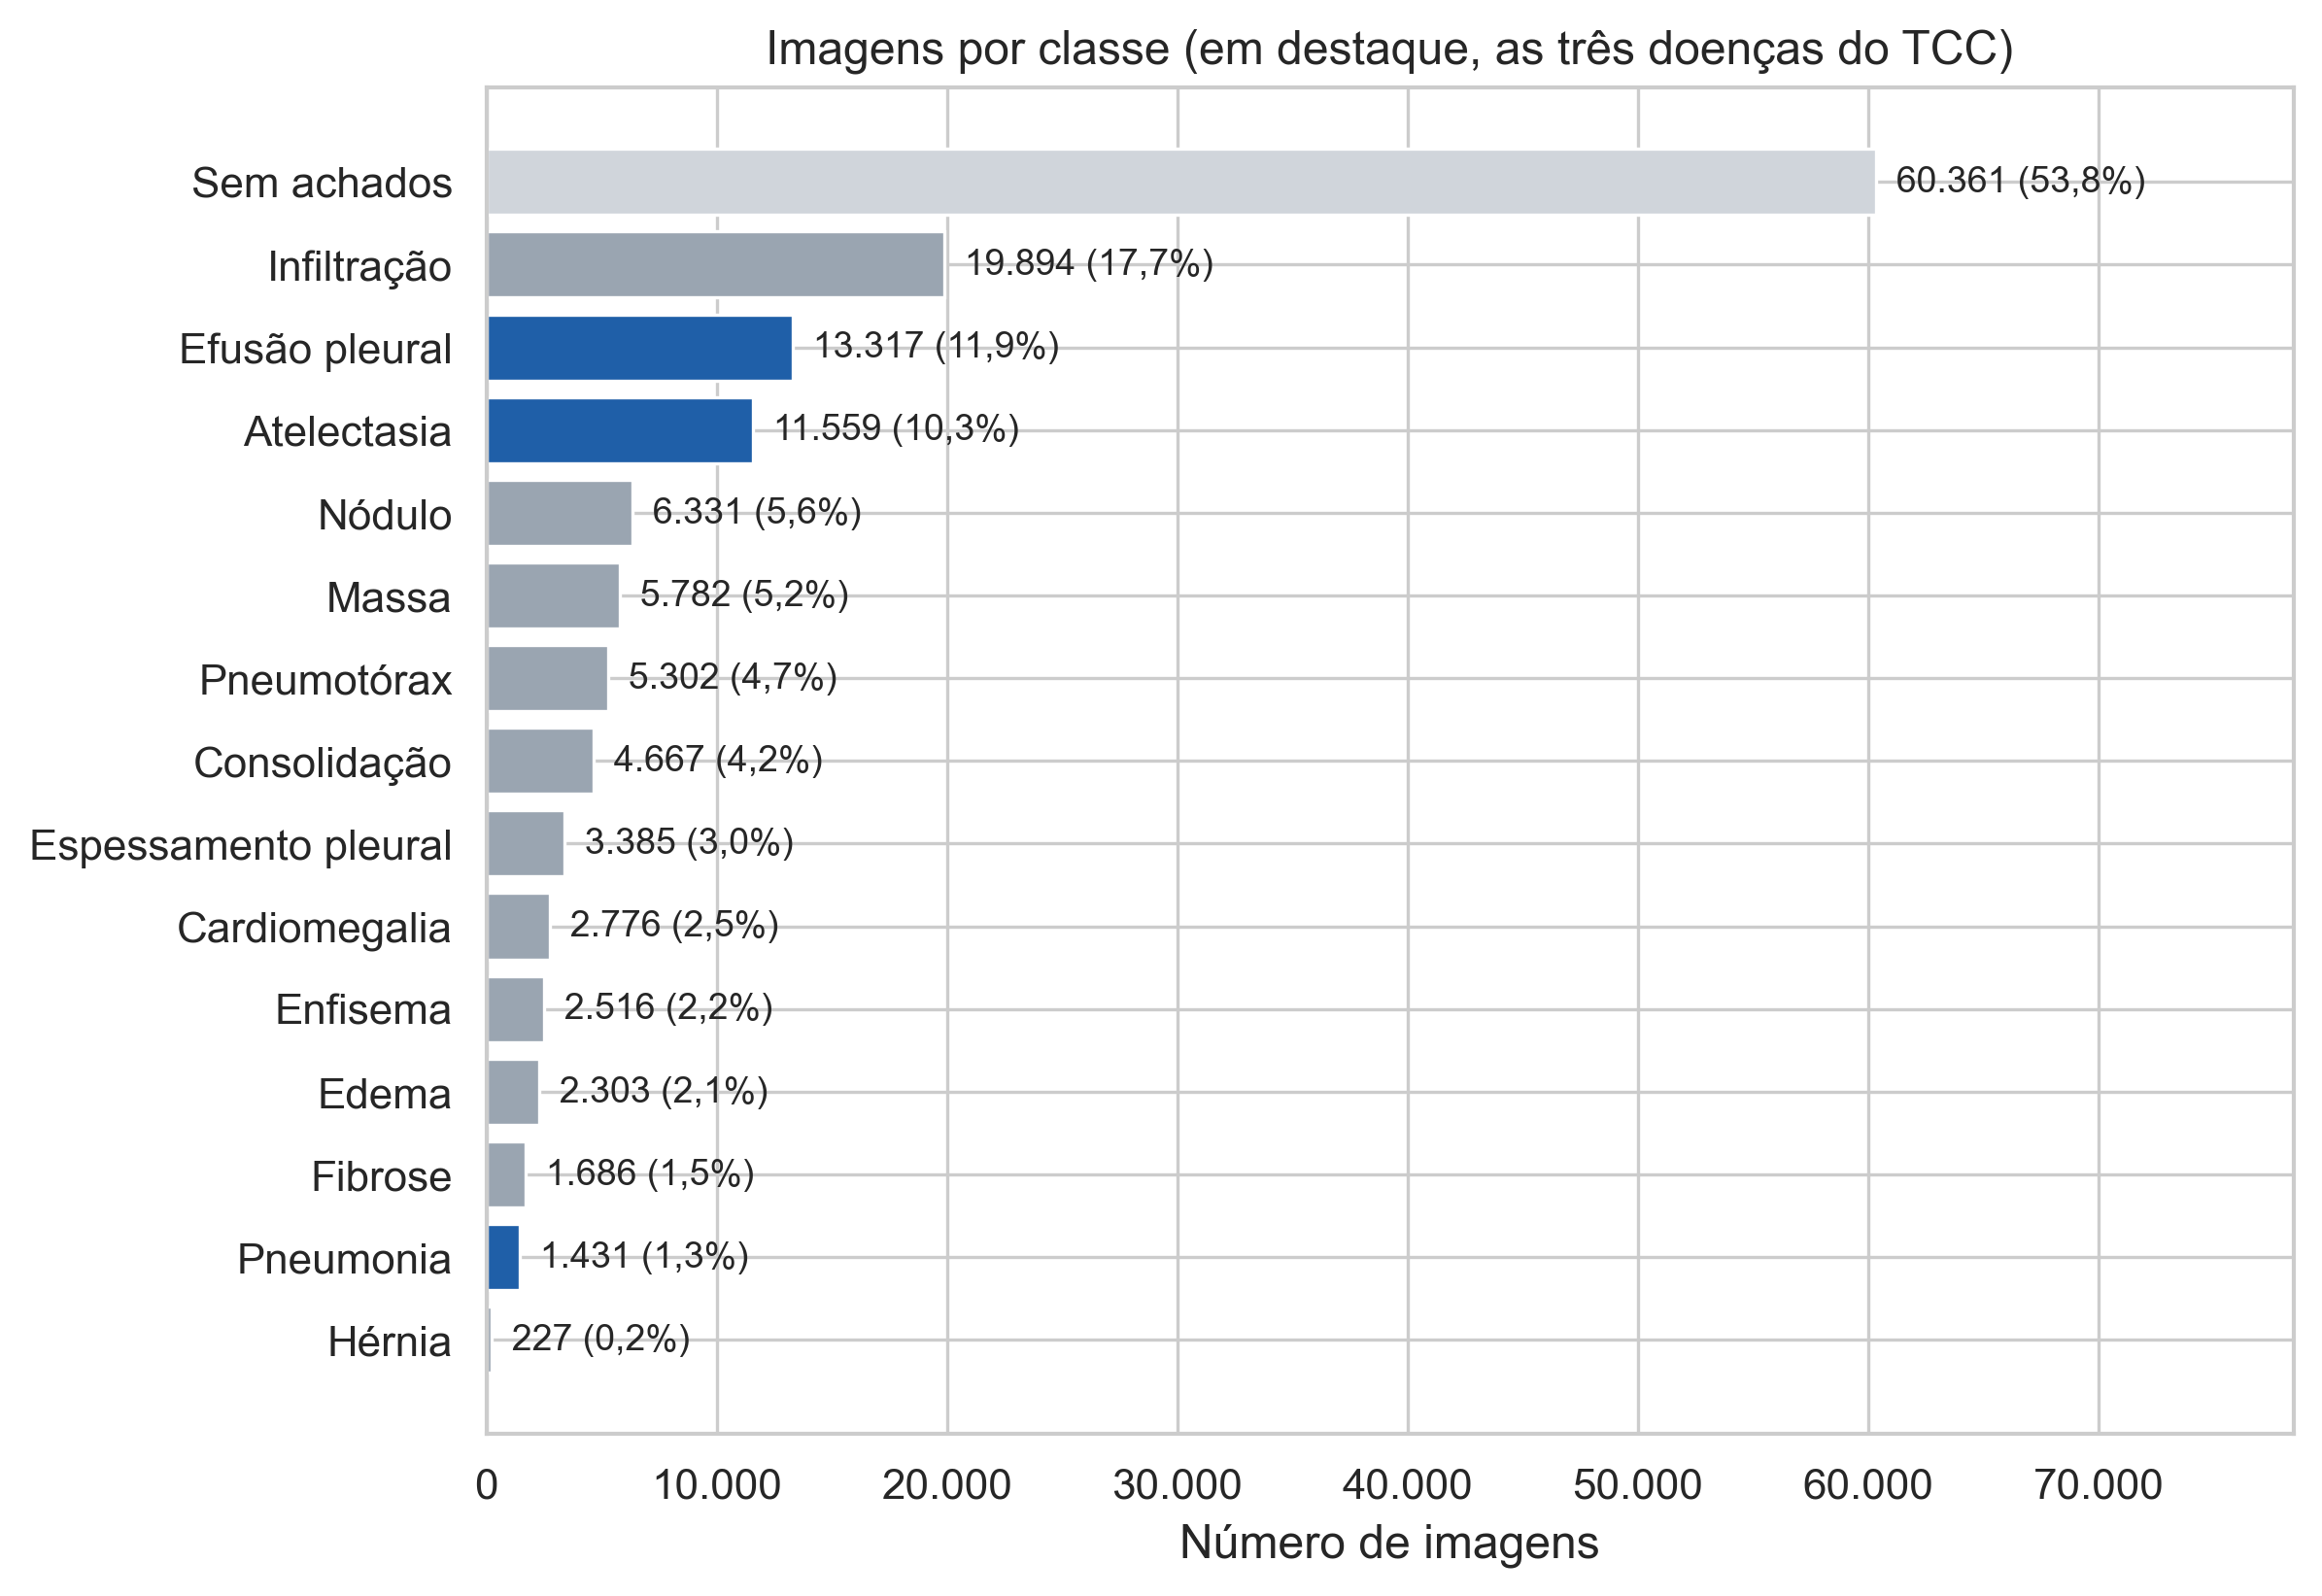

,classe_pt,n,pct,pct_ap
classe,,,,
Atelectasis,Atelectasia,11559,10.31,50.45
Cardiomegaly,Cardiomegalia,2776,2.48,43.70
Effusion,Efusão pleural,13317,11.88,50.52
Infiltration,Infiltração,19894,17.74,52.99
Mass,Massa,5782,5.16,38.31
Nodule,Nódulo,6331,5.65,34.02
Pneumonia,Pneumonia,1431,1.28,55.97
Pneumothorax,Pneumotórax,5302,4.73,35.74
Consolidation,Consolidação,4667,4.16,67.41


In [3]:
show("eda_prevalencia")
counts.round(2)

## Co-ocorrência de doenças

Muitas imagens têm mais de uma doença ao mesmo tempo. Por isso o problema é tratado como
**multirrótulo**: uma saída sigmoid independente por classe, e não uma escolha exclusiva entre
classes (softmax). A diagonal mostra o total de cada classe; células vazias indicam que o par nunca
aparece junto.

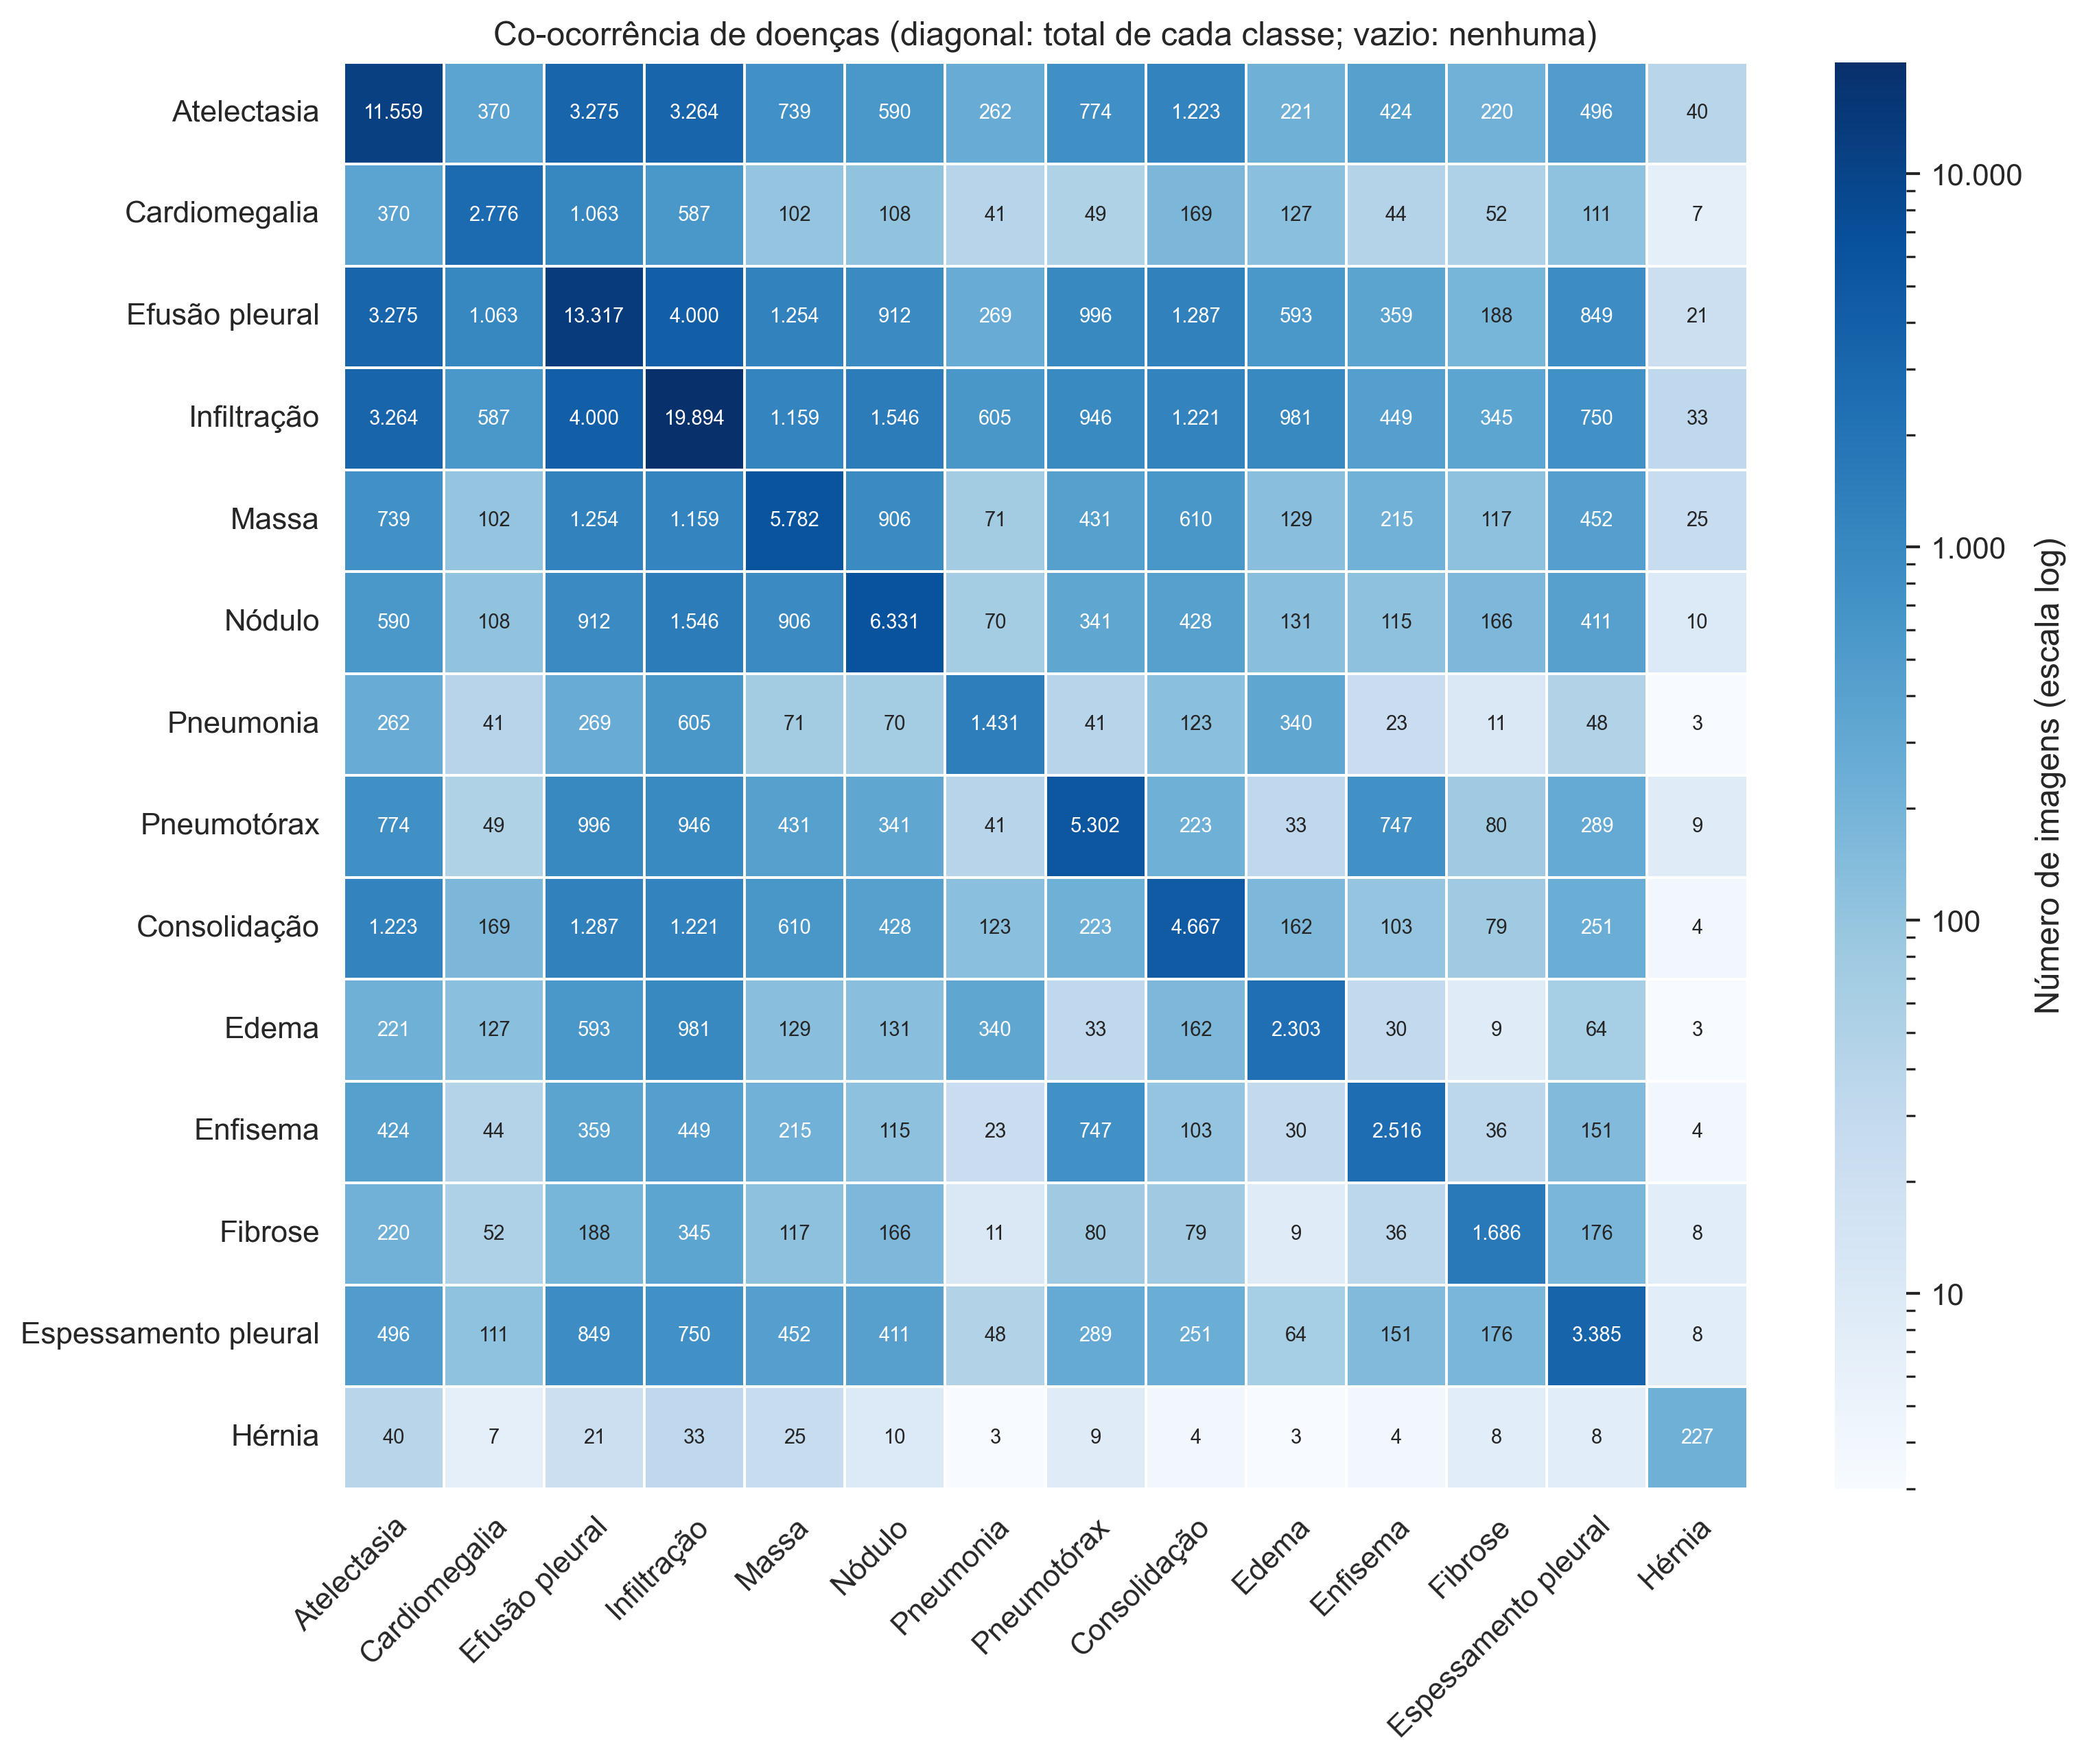

In [4]:
show("eda_coocorrencia", width=900)

## Imagens por paciente

A maioria dos pacientes tem uma única imagem, mas alguns têm dezenas (acompanhamento de pacientes
internados). Imagens do mesmo paciente são muito parecidas entre si, então a divisão em
treino/validação/teste é feita **por paciente** (seção 3.1 do plano): dividir por imagem colocaria
exames do mesmo paciente no treino e no teste e inflaria a AUC.

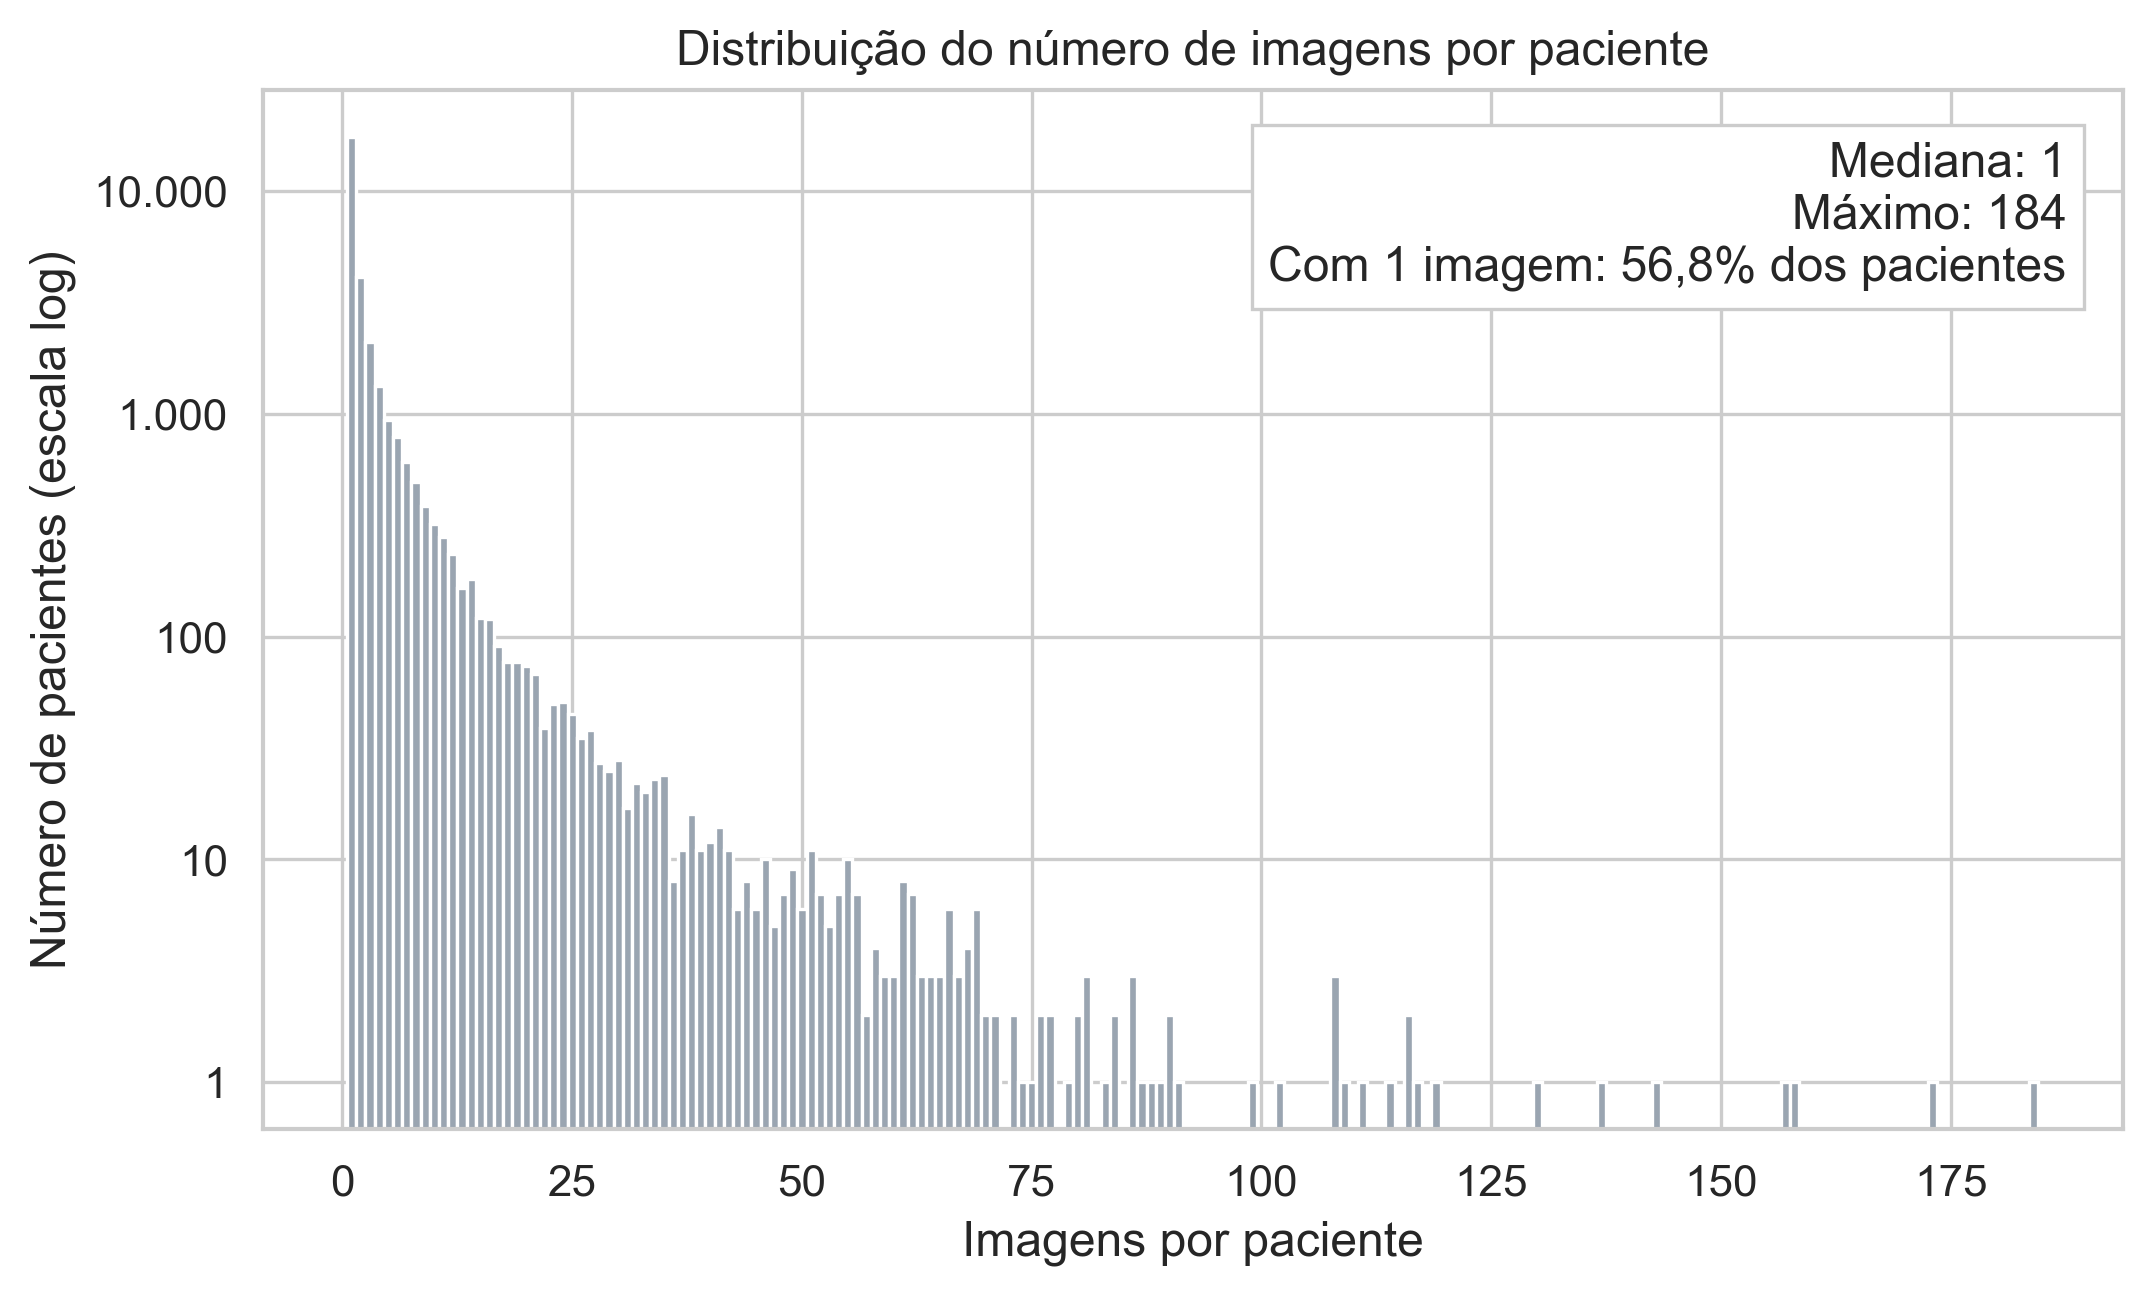

In [5]:
show("eda_imagens_por_paciente")

## Idade e sexo

O CSV traz algumas idades impossíveis (acima de 100 anos). Elas ficam fora só deste gráfico; a
quantidade está na tabela de resumo e deve ser citada na monografia.

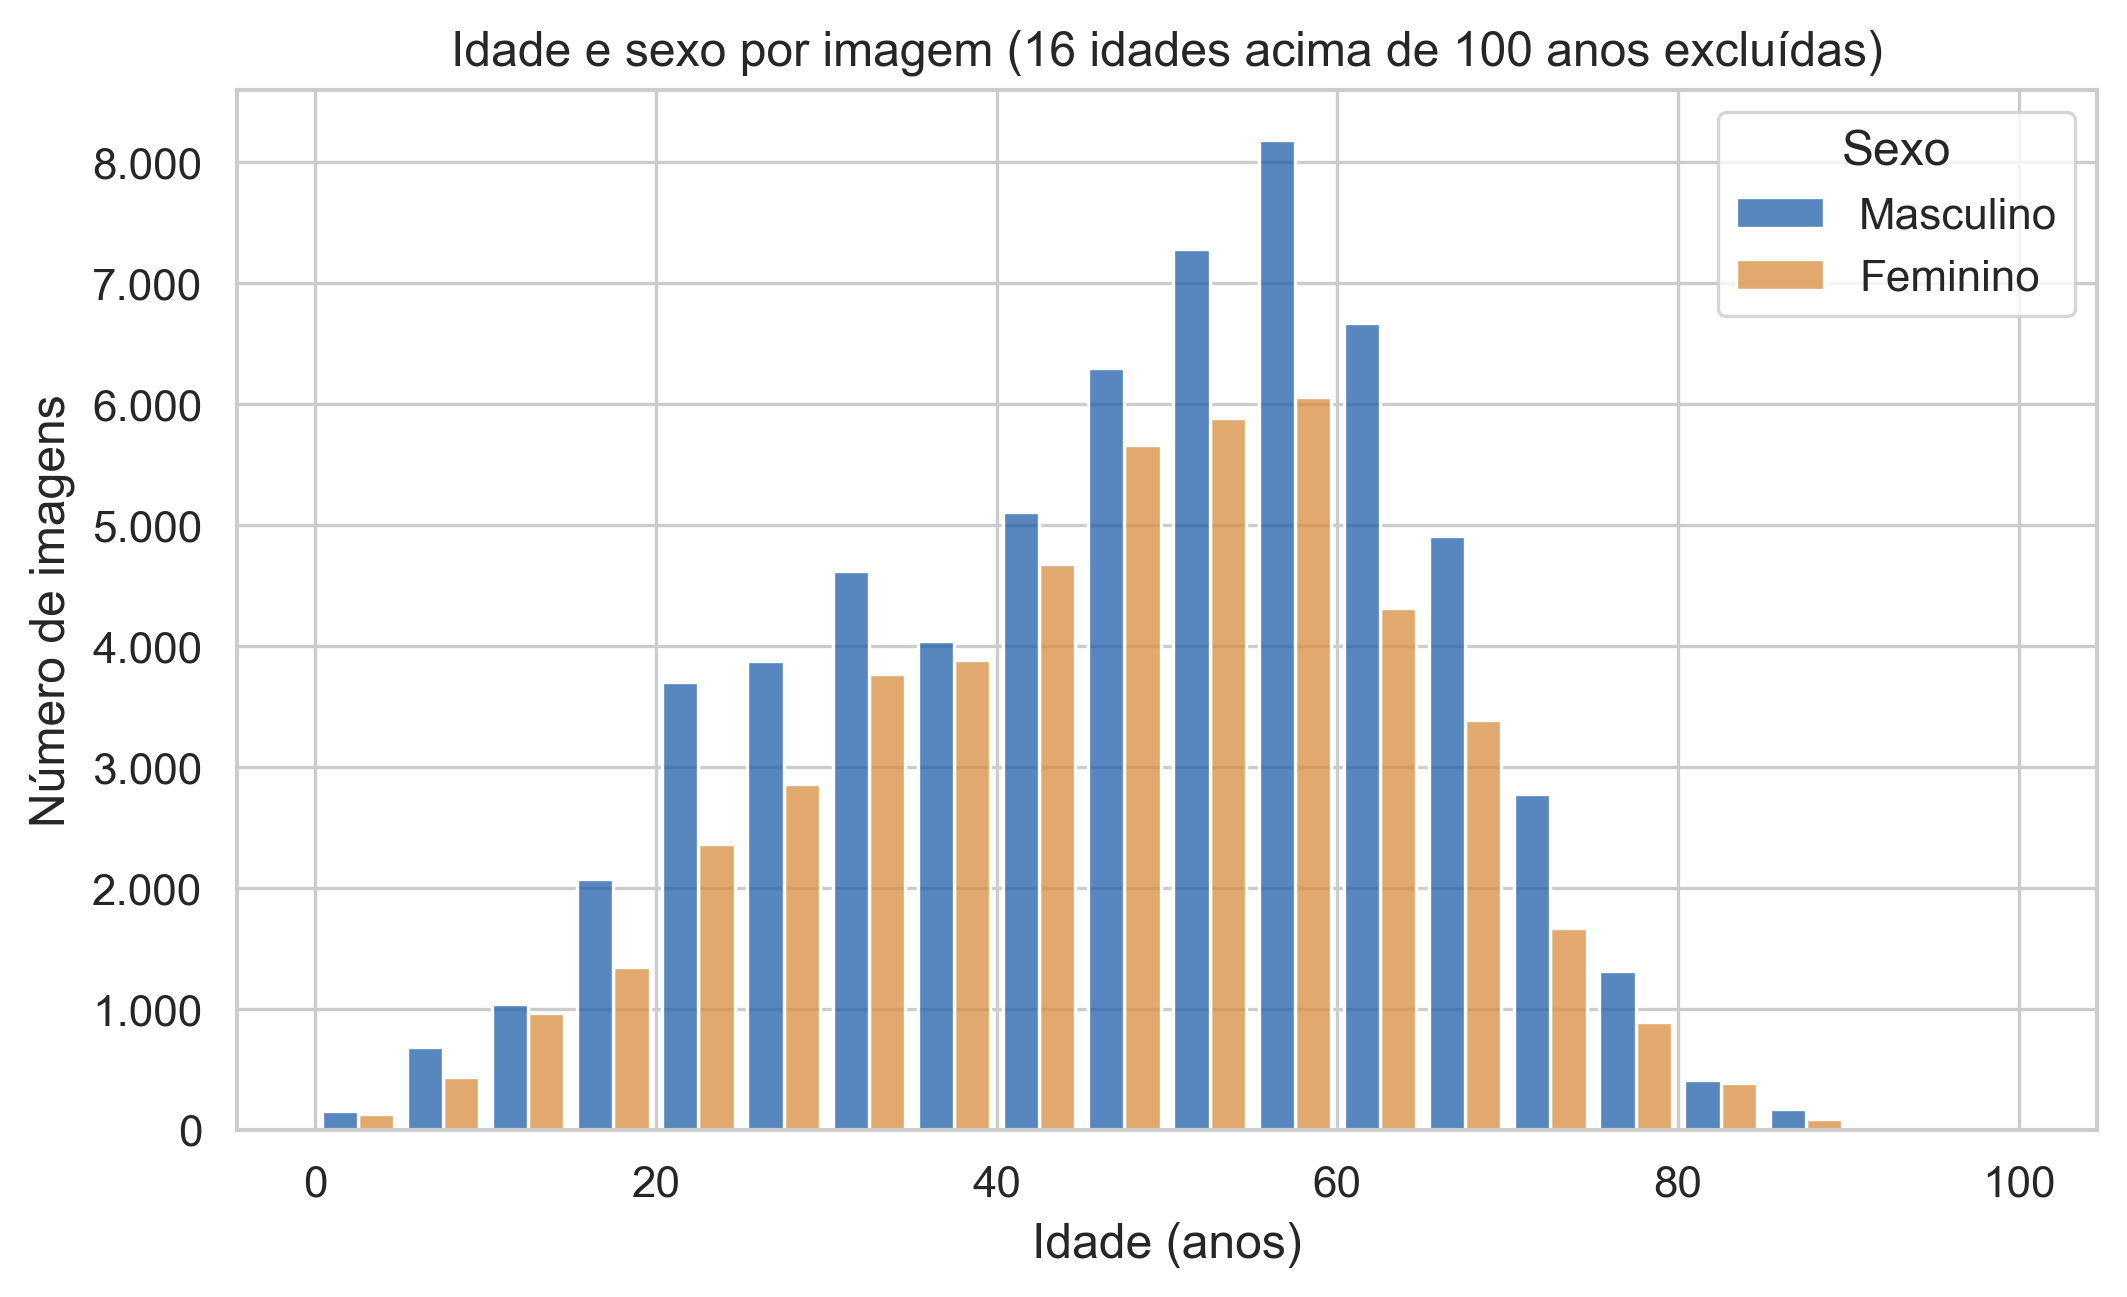

In [6]:
show("eda_idade_sexo")

## Incidência AP × PA por classe

A radiografia PA é feita com o paciente em pé; a AP, em geral no leito, com pacientes mais graves ou
internados. Classes com proporção de AP bem acima da média podem ensinar ao modelo um **atalho**: ele
pode aprender a reconhecer a incidência (ou o paciente acamado) em vez da doença. Isso motiva a análise
por subgrupo PA × AP na Fase 3.

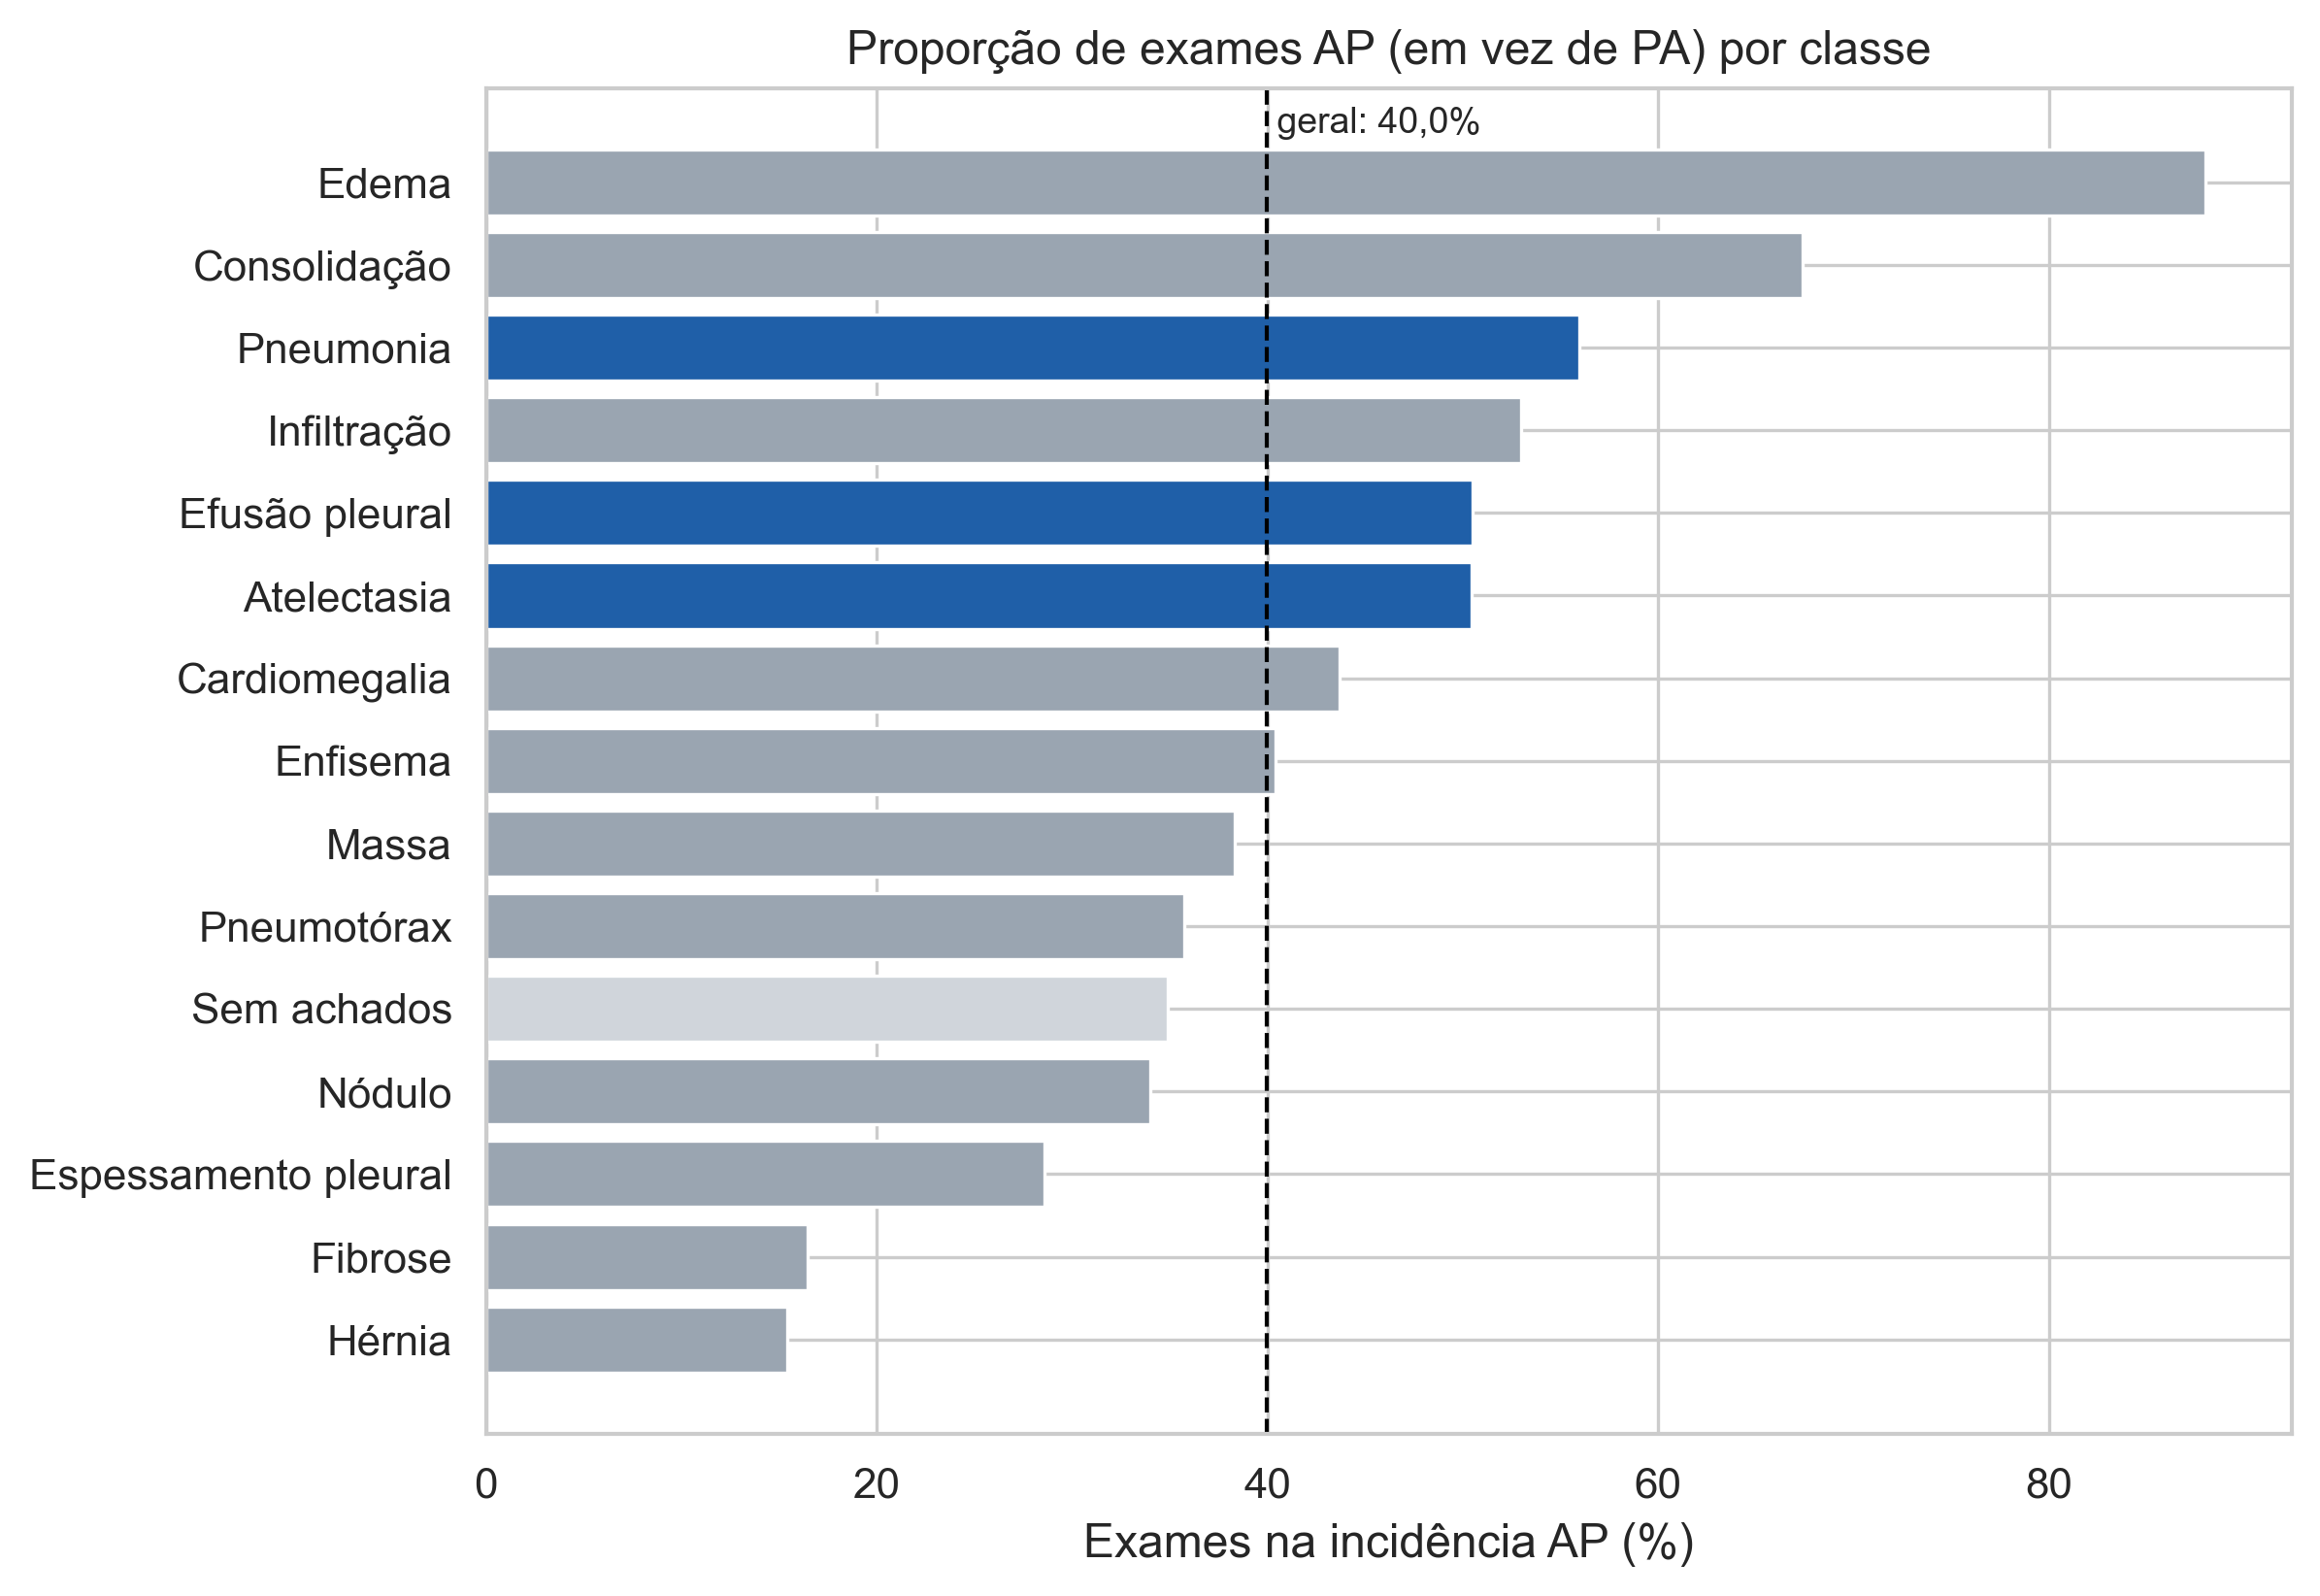

AP geral: 40,0%. Classes com mais de 10 pontos acima:
  Edema: 88,0% AP
  Consolidação: 67,4% AP
  Pneumonia: 56,0% AP
  Infiltração: 53,0% AP
  Efusão pleural: 50,5% AP
  Atelectasia: 50,4% AP


In [7]:
show("eda_ap_pa")
overall_ap = summary.set_index("metrica").loc["Exames AP (%)", "valor"]
above = counts[counts["pct_ap"] > overall_ap + 10].sort_values("pct_ap", ascending=False)
print(f"AP geral: {br_number(overall_ap, 1)}%. Classes com mais de 10 pontos acima:")
for name, row in above.iterrows():
    print(f"  {pt(name)}: {br_number(row['pct_ap'], 1)}% AP")

## Exemplos de imagens

Imagens com um único rótulo, sorteadas com seed fixa (não escolhidas a dedo), já no tamanho
armazenado (256×256). Vale notar os dispositivos (cabos, eletrodos, sondas) e as marcações de texto:
também são possíveis atalhos, mais comuns em pacientes internados.

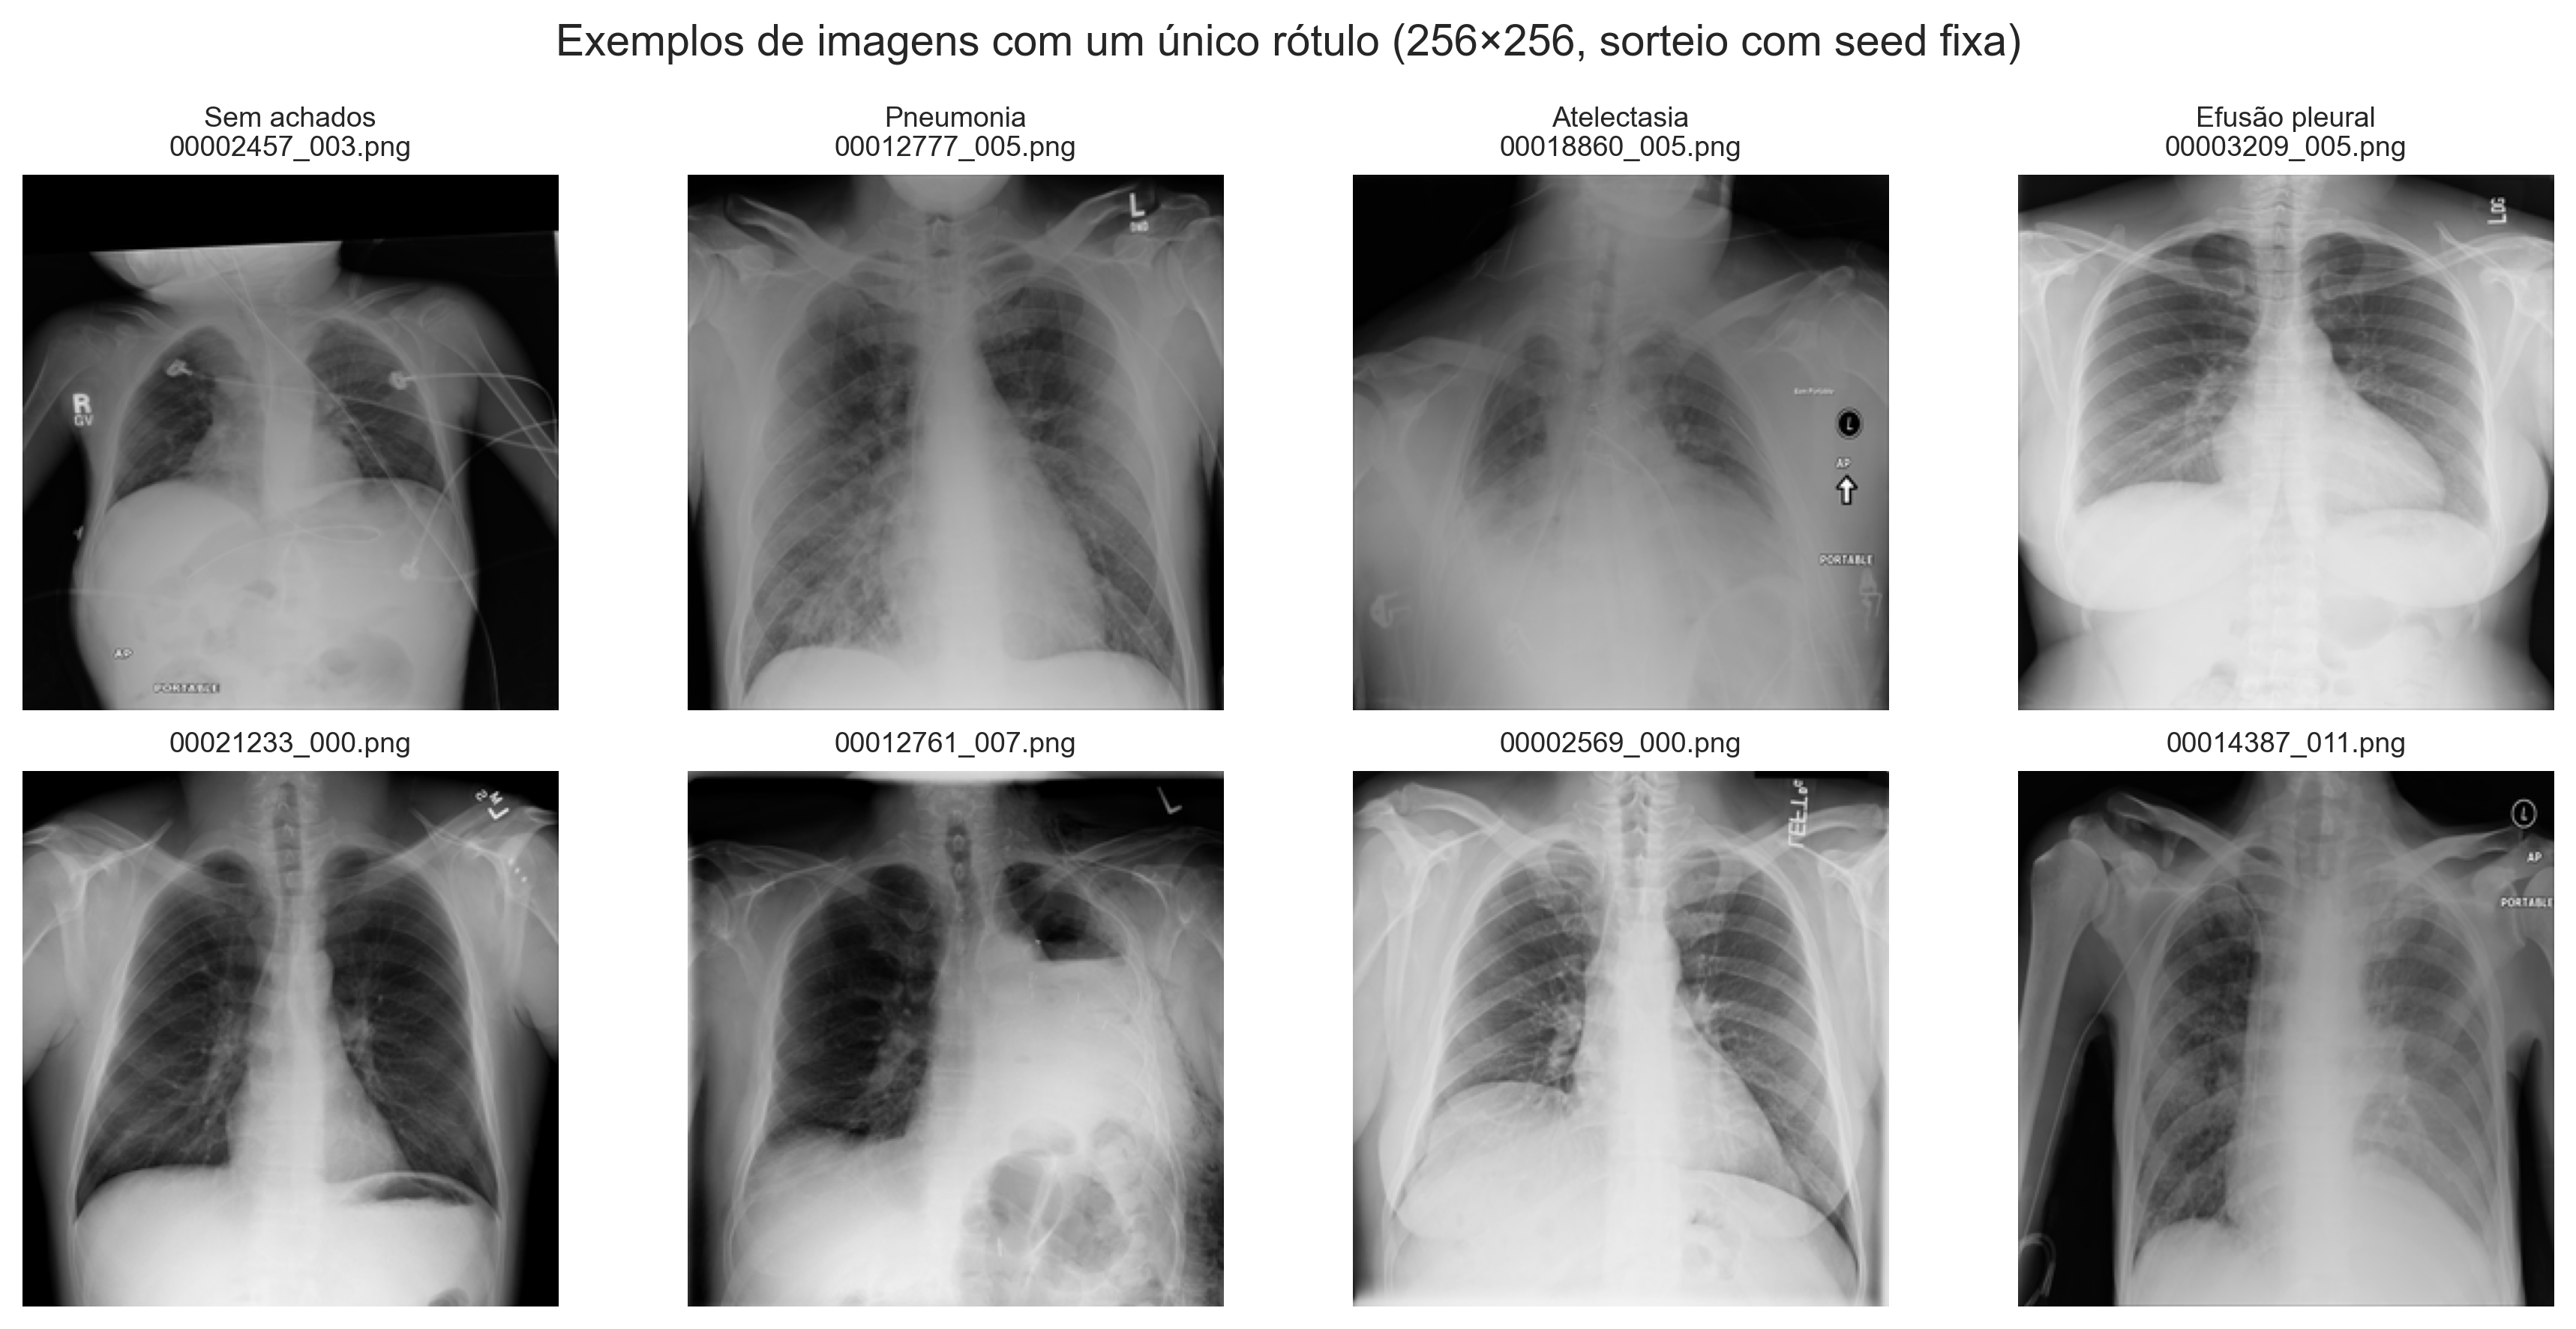

In [8]:
show("eda_exemplos", width=950)

## Resumo para a monografia

Frases prontas com os números calculados acima (formato brasileiro).

In [9]:
s = summary.set_index("metrica")["valor"]
print(f"{br_number(s['Imagens'])} imagens de {br_number(s['Pacientes'])} pacientes; "
      f"{br_number(s['Imagens sem achados (%)'], 1)}% sem achados e "
      f"{br_number(s['Imagens com 2 ou mais doenças (%)'], 1)}% com duas ou mais doenças.")
for cls in cfg["data"]["focus_classes"]:
    row = counts.loc[cls]
    print(f"{pt(cls)}: {br_number(row['n'])} imagens ({br_number(row['pct'], 1)}%), "
          f"{br_number(row['pct_ap'], 1)}% em AP.")
print(f"Imagens por paciente: mediana {br_number(s['Imagens por paciente: mediana'])}, "
      f"máximo {br_number(s['Imagens por paciente: máximo'])}; "
      f"{br_number(s['Pacientes com 1 imagem (%)'], 1)}% dos pacientes têm uma única imagem.")
print(f"Idade mediana {br_number(s['Idade: mediana (anos)'])} anos "
      f"(IQR {br_number(s['Idade: 1º quartil (anos)'])}–{br_number(s['Idade: 3º quartil (anos)'])}); "
      f"{br_number(s['Idades acima de 100 anos (excluídas do gráfico)'])} idade(s) acima de 100 anos no CSV.")
print(f"{br_number(s['Imagens de pacientes do sexo feminino (%)'], 1)}% das imagens são de pacientes do sexo "
      f"feminino; {br_number(s['Exames AP (%)'], 1)}% dos exames são AP.")

112.120 imagens de 30.805 pacientes; 53,8% sem achados e 18,5% com duas ou mais doenças.
Pneumonia: 1.431 imagens (1,3%), 56,0% em AP.
Atelectasia: 11.559 imagens (10,3%), 50,4% em AP.
Efusão pleural: 13.317 imagens (11,9%), 50,5% em AP.
Imagens por paciente: mediana 1, máximo 184; 56,8% dos pacientes têm uma única imagem.
Idade mediana 49 anos (IQR 35–59); 16 idade(s) acima de 100 anos no CSV.
43,5% das imagens são de pacientes do sexo feminino; 40,0% dos exames são AP.
